# Drug-Patient QGNN Training with PySpark

In [1]:
# Spark Configuration
SPARK_MASTER = "local[*]"        # "local[*]" = all cores, or "spark://host:port"
SPARK_MEMORY = "8g"              # Driver memory
SPARK_EXECUTOR_MEMORY = "4g"     # Executor memory
NUM_EXECUTORS = 6                # Number of executors (for cluster mode)

# Data paths
DATA_DIR = "/media/priyanshu/SD/othercode/data"  # Path to PDB data
SAVE_DIR = "./saved_models"                      # Where to save models

# Data parameters
MAX_DRUGS = None             # Max drugs to load (None = all)
N_PATIENTS = 200            # Number of synthetic patients
INTERACTION_RATE = 0.05      # Fraction of drug-patient pairs to create

# Model parameters
NUM_QUBITS = 6               # Qubits per side (total = 2 * NUM_QUBITS)
NUM_QLAYERS = 2              # Number of variational layers
HIDDEN_DIM = 64              # Hidden dimension for encoders
USE_QUANTUM = False          # Note: Quantum mode not fully parallelizable with Spark

# Training parameters
EPOCHS = 100                 # Number of training epochs
BATCH_SIZE = 64              # Batch size (larger for distributed)
LEARNING_RATE = 0.001        # Learning rate
VAL_SPLIT = 0.2              # Validation split (0.2 = 20%)
EARLY_STOPPING = None        # Early stopping patience (None = disabled)

# Spark-specific parameters
PARTITION_SIZE = 100         # Samples per partition
SHUFFLE_PARTITIONS = 200     # Number of shuffle partitions

# Other parameters
SEED = 42                    # Random seed
DEVICE = None                # Device (None = auto-detect, 'cuda', 'mps', 'cpu')
VERBOSE = 2                  # Verbosity (0=silent, 1=progress, 2=detailed)

# ============================================================================

## Setup Spark and Imorts

In [2]:
import importlib
import drug_patient_qgnn.data_processing
import drug_patient_qgnn

# Reload module first to get new class definition
importlib.reload(drug_patient_qgnn.data_processing)
# Reload package to update __init__ imports
importlib.reload(drug_patient_qgnn)

print('Force reloaded DrugProteinDataProcessor and package')

%load_ext autoreload
%autoreload 2

import os
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

# PySpark imports
try:
    from pyspark.sql import SparkSession
    from pyspark.sql.functions import col, udf, pandas_udf, PandasUDFType
    from pyspark.sql.types import *
    from pyspark import SparkContext, SparkConf
    PYSPARK_AVAILABLE = True
except ImportError:
    print(" PySpark not installed. Installing...")
    print("Run: pip install pyspark")
    PYSPARK_AVAILABLE = False

# Import drug-patient QGNN
from drug_patient_qgnn import (
    DrugPatientDataProcessor,
    QuantumDrugPatientGNN,
    DrugPatientTrainer,
    set_seed,
    print_model_summary,
    print_device_info,
    plot_training_history,
    calculate_metrics,
    print_metrics
)

# Set random seed
set_seed(SEED)

# Create save directory
os.makedirs(SAVE_DIR, exist_ok=True)

# Create experiment name
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
mode = "quantum" if USE_QUANTUM else "classical"
EXPERIMENT_NAME = f"spark_{mode}_q{NUM_QUBITS}_l{NUM_QLAYERS}_{timestamp}"


print(f"Experiment: {EXPERIMENT_NAME}")
print(f"Mode: {'QUANTUM' if USE_QUANTUM else 'CLASSICAL'} + SPARK")
print(f"Spark Master: {SPARK_MASTER}")
print(f"Qubits: {NUM_QUBITS} per side (total: {2*NUM_QUBITS})")
print(f"Layers: {NUM_QLAYERS}")
print(f"Epochs: {EPOCHS}")
print(f"Batch Size: {BATCH_SIZE}")

import drug_patient_qgnn
print(f'Using drug_patient_qgnn from: {drug_patient_qgnn.__file__}')


Force reloaded DrugProteinDataProcessor and package
Experiment: spark_classical_q6_l2_20251128_140339
Mode: CLASSICAL + SPARK
Spark Master: local[*]
Qubits: 6 per side (total: 12)
Layers: 2
Epochs: 100
Batch Size: 64
Using drug_patient_qgnn from: /home/priyanshu/QuantumGNN-/Actuall/drug_patient_qgnn/__init__.py


In [3]:

import subprocess
import glob

def find_java_home():
    """Try to find JAVA_HOME automatically, prioritizing Java 17."""
    # Common Java installation paths (PRIORITIZE JAVA 17)
    java_paths = [
        '/usr/lib/jvm/java-17-openjdk-amd64',  # Java 17 first
        '/usr/lib/jvm/java-11-openjdk-amd64',
        '/usr/lib/jvm/java-8-openjdk-amd64',
        '/usr/lib/jvm/default-java',
    ]
    
    # Check each path
    for path in java_paths:
        if os.path.exists(path):
            return path
    
    # Try to find Java 17 using glob pattern first
    jvm_dirs_17 = glob.glob('/usr/lib/jvm/java-17*')
    if jvm_dirs_17:
        return sorted(jvm_dirs_17)[-1]
    
    # Try to find using update-alternatives
    try:
        result = subprocess.run(['readlink', '-f', '/usr/bin/java'], 
                              capture_output=True, text=True, timeout=5)
        if result.returncode == 0:
            java_bin = result.stdout.strip()
            # Extract JAVA_HOME (remove /bin/java)
            java_home = java_bin.replace('/bin/java', '')
            if os.path.exists(java_home):
                return java_home
    except:
        pass
    
    # Try glob pattern for any Java version
    jvm_dirs = glob.glob('/usr/lib/jvm/java-*-openjdk-*')
    if jvm_dirs:
        return sorted(jvm_dirs)[-1]  # Return newest version
    
    return None

# Check if JAVA_HOME is already set
if 'JAVA_HOME' not in os.environ:
    java_home = find_java_home()
    
    if java_home:
        os.environ['JAVA_HOME'] = java_home
        print(f"✓ JAVA_HOME automatically set to: {java_home}")
    else:
        print("JAVA NOT FOUND - INSTALLATION REQUIRED")
        print("\nPySpark requires Java (JDK 17 recommended). Please install it:")
        print("\nOpen a terminal and run:")
        print("  sudo apt update")
        print("  sudo apt install -y openjdk-17-jdk")
        print("\nAfter installation, restart this notebook.")
        
        raise RuntimeError(
            "Java is not installed. Please install Java and restart the notebook."
        )
else:
    print(f"✓ JAVA_HOME already set: {os.environ['JAVA_HOME']}")

# Verify Java is working
try:
    result = subprocess.run(['java', '-version'], 
                          capture_output=True, text=True, timeout=5)
    version_output = result.stderr.split('\n')[0]  # Java version goes to stderr
    print(f"✓ Java version: {version_output}")
    
    # Check if we're using the right Java version
    if 'JAVA_HOME' in os.environ:
        java_executable = os.path.join(os.environ['JAVA_HOME'], 'bin', 'java')
        if os.path.exists(java_executable):
            result_home = subprocess.run([java_executable, '-version'],
                                       capture_output=True, text=True, timeout=5)
            version_home = result_home.stderr.split('\n')[0]
            print(f"✓ JAVA_HOME Java version: {version_home}")
except Exception as e:
    print(f"⚠️  Warning: Could not verify Java installation: {e}")

✓ JAVA_HOME already set: /usr/lib/jvm/java-17-openjdk-amd64
✓ Java version: openjdk version "17.0.17" 2025-10-21
✓ JAVA_HOME Java version: openjdk version "17.0.17" 2025-10-21


In [4]:
if not PYSPARK_AVAILABLE:
    raise ImportError("PySpark is required. Install with: pip install pyspark")

# Configure Spark
conf = SparkConf() \
    .setAppName("DrugPatientQGNN") \
    .setMaster(SPARK_MASTER) \
    .set("spark.driver.memory", SPARK_MEMORY) \
    .set("spark.executor.memory", SPARK_EXECUTOR_MEMORY) \
    .set("spark.sql.shuffle.partitions", str(SHUFFLE_PARTITIONS)) \
    .set("spark.default.parallelism", str(SHUFFLE_PARTITIONS))

# Create Spark session
spark = SparkSession.builder \
    .config(conf=conf) \
    .getOrCreate()

# Get Spark context
sc = spark.sparkContext
sc.setLogLevel("WARN")  # Reduce logging noise


print("Spark Session Initialized")

print(f"Spark Version: {spark.version}")
print(f"Master: {spark.sparkContext.master}")
print(f"App Name: {spark.sparkContext.appName}")
print(f"Default Parallelism: {spark.sparkContext.defaultParallelism}")


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/11/28 14:03:40 WARN Utils: Your hostname, priyanshu-linux, resolves to a loopback address: 127.0.1.1; using 10.0.0.74 instead (on interface enp5s0)
25/11/28 14:03:40 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/28 14:03:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/28 14:03:41 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark Session Initialized
Spark Version: 4.0.1
Master: local[*]
App Name: DrugPatientQGNN
Default Parallelism: 200


In [5]:
print_device_info()


Device Information
CUDA Available      : True
CUDA Devices        : 1
CUDA Device Name    : NVIDIA GeForce RTX 3080
MPS Available       : False



## Step 1: Load and Process Data with Spark

In [6]:
print("Loading Data with Spark")

# Initialize processor
processor = DrugPatientDataProcessor(data_dir=DATA_DIR, seed=SEED)

# Load real data (Proteins, Drugs, Interactions) from PDB
print(f"\nLoading real data from: {DATA_DIR}")
counts = processor.load_real_data(data_dir=DATA_DIR, max_samples=MAX_DRUGS)

if counts["interactions"] == 0:
    print("\nWarning: No interactions loaded. Pipeline might fail.")

# Get statistics
stats = processor.get_statistics()
print("\nDataset Statistics:")
for key, value in stats.items():
    if isinstance(value, float):
        print(f"{key:25s}: {value:.4f}")
    else:
        print(f"{key:25s}: {value}")


Loading Data with Spark

Loading real data from: /media/priyanshu/SD/othercode/data
Searching for data in: /media/priyanshu/SD/othercode/data
Found 15239 protein descriptor files


Loading PDB Data: 100%|██████████| 15239/15239 [00:35<00:00, 423.91it/s]


Loaded 13201 proteins, 122130 drugs, 122130 interactions

Dataset Statistics:
num_ligands              : 61107
num_pockets              : 12636
num_interactions         : 122130
num_drugs                : 61107
num_patients             : 12636
positive_rate            : 1.0000
negative_rate            : 0.0000
ligand_feature_dim       : 19
drug_feature_dim         : 19
pocket_feature_dim       : 19
patient_feature_dim      : 19


In [7]:

print("Creating Spark DataFrames")


# Get graph data
graph = processor.graph
drug_features = graph.get_drug_features_matrix()
patient_features = graph.get_patient_features_matrix()
edge_index, edge_features = graph.get_edge_index()
labels = graph.get_edge_labels()

# Create interaction dataset
interaction_data = []
for idx in range(edge_index.shape[1]):
    drug_idx = int(edge_index[0, idx])
    patient_idx = int(edge_index[1, idx])
    
    interaction_data.append({
        'interaction_id': idx,
        'drug_idx': drug_idx,
        'patient_idx': patient_idx,
        'drug_features': drug_features[drug_idx].tolist(),
        'patient_features': patient_features[patient_idx].tolist(),
        'label': float(labels[idx])
    })

# Create pandas DataFrame
df_pandas = pd.DataFrame(interaction_data)

# Convert to Spark DataFrame
df_spark = spark.createDataFrame(df_pandas)

# Partition data
n_partitions = max(1, len(interaction_data) // PARTITION_SIZE)
df_spark = df_spark.repartition(n_partitions)

# Cache for faster access
df_spark.cache()

print(f"\n✓ Created Spark DataFrame with {df_spark.count()} interactions")
print(f"✓ Number of partitions: {df_spark.rdd.getNumPartitions()}")
print(f"\nSchema:")
df_spark.printSchema()

# Show sample
print("\nSample data:")
df_spark.select('interaction_id', 'drug_idx', 'patient_idx', 'label').show(5)

Creating Spark DataFrames



✓ Created Spark DataFrame with 122130 interactions
✓ Number of partitions: 1221

Schema:
root
 |-- interaction_id: long (nullable = true)
 |-- drug_idx: long (nullable = true)
 |-- patient_idx: long (nullable = true)
 |-- drug_features: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- patient_features: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- label: double (nullable = true)


Sample data:
+--------------+--------+-----------+-----+
|interaction_id|drug_idx|patient_idx|label|
+--------------+--------+-----------+-----+
|          2671|       1|        282|  1.0|
|          4282|    2171|        486|  1.0|
|          5326|    2693|        603|  1.0|
|          6048|      12|        690|  1.0|
|          6997|    3528|        795|  1.0|
+--------------+--------+-----------+-----+
only showing top 5 rows


In [8]:

print("Train/Validation Split")

# Check label distribution before split
print("\nOverall Label Distribution:")
print(df_pandas['label'].value_counts())

# Stratified Split using sklearn
train_pd, val_pd = train_test_split(
    df_pandas,
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=df_pandas['label']
)

print("\nTrain Label Distribution:")
print(train_pd['label'].value_counts())
print("\nValidation Label Distribution:")
print(val_pd['label'].value_counts())

# Convert to Spark DataFrame (optional)
train_df = spark.createDataFrame(train_pd)
val_df = spark.createDataFrame(val_pd)

train_df = train_df.repartition(max(1, len(train_pd) // PARTITION_SIZE)).cache()
val_df = val_df.repartition(max(1, len(val_pd) // PARTITION_SIZE)).cache()

print(f"\nTraining samples: {len(train_pd)}")
print(f"Validation samples: {len(val_pd)}")

# Create PyTorch Datasets and Loaders
print("\nCreating PyTorch DataLoaders")

class InteractionDataset(Dataset):
    def __init__(self, df):
        self.drug_features = np.stack(df['drug_features'].values)
        self.patient_features = np.stack(df['patient_features'].values)
        self.labels = df['label'].values.astype(np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.drug_features[idx], dtype=torch.float32),
            torch.tensor(self.patient_features[idx], dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.float32),
        )

train_dataset = InteractionDataset(train_pd)
val_dataset = InteractionDataset(val_pd)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


Train/Validation Split



Training samples: 97500
Validation samples: 24630
Train partitions: 1221
Val partitions: 1221


In [9]:

print("Creating Model")


# Get feature dimensions
drug_dim = len(drug_features[0])
patient_dim = len(patient_features[0])

# Create model
model = QuantumDrugPatientGNN(
    drug_dim=drug_dim,
    patient_dim=patient_dim,
    num_qubits=NUM_QUBITS,
    num_qlayers=NUM_QLAYERS,
    hidden_dim=HIDDEN_DIM,
    use_quantum=USE_QUANTUM
)

# Print model summary
print_model_summary(model, drug_dim, patient_dim)

if USE_QUANTUM:
    print("\n  Note: Quantum mode with Spark may not provide speedup")
    print("   Quantum circuits are not easily parallelizable")
    print("   Consider USE_QUANTUM=False for distributed training")
else:
    print("\n✓ Classical mode - fully compatible with Spark distribution")

Creating Model

Model Summary
ligand_dim          : 19
pocket_dim          : 19
num_qubits          : 6
num_qlayers         : 2
use_quantum         : False
num_parameters      : 4101
drug_dim            : 19
patient_dim         : 19
Total parameters    : 4,101
Trainable params    : 4,101
Input (drug)        : (19,)
Input (patient)     : (19,)
Output              : (1,) [probability]


✓ Classical mode - fully compatible with Spark distribution


In [10]:
def train_epoch(model, optimizer, criterion, loader, device):
    """Train one epoch using PyTorch DataLoader."""
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    for drug_features, patient_features, labels in loader:
        drug_features = drug_features.to(device)
        patient_features = patient_features.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(drug_features, patient_features).squeeze(-1)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        batch_size_actual = len(labels)
        total_loss += loss.item() * batch_size_actual
        all_preds.extend(outputs.detach().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    from sklearn.metrics import accuracy_score
    avg_loss = total_loss / len(all_labels)
    accuracy = accuracy_score(all_labels, (np.array(all_preds) >= 0.5).astype(int))
    
    return {'loss': avg_loss, 'accuracy': accuracy}

def evaluate(model, criterion, loader, device):
    """Evaluate model using PyTorch DataLoader."""
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for drug_features, patient_features, labels in loader:
            drug_features = drug_features.to(device)
            patient_features = patient_features.to(device)
            labels = labels.to(device)
            
            outputs = model(drug_features, patient_features).squeeze(-1)
            loss = criterion(outputs, labels)
            
            batch_size_actual = len(labels)
            total_loss += loss.item() * batch_size_actual
            all_preds.extend(outputs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    from sklearn.metrics import accuracy_score, roc_auc_score
    avg_loss = total_loss / len(all_labels)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    accuracy = accuracy_score(all_labels, (all_preds >= 0.5).astype(int))
    auc = roc_auc_score(all_labels, all_preds) if len(np.unique(all_labels)) > 1 else float('nan')
    
    return {'loss': avg_loss, 'accuracy': accuracy, 'auc': auc}

print("\n✓ Training functions defined")



✓ Distributed training functions defined


In [11]:


# Setup training
device = torch.device(DEVICE if DEVICE else (
    'cuda' if torch.cuda.is_available() else
    'mps' if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available() else
    'cpu'
))

model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = torch.nn.BCELoss()

print(f"\nDevice: {device}")
print(f"Optimizer: Adam (lr={LEARNING_RATE})")
print(f"Loss: Binary Cross-Entropy")
print("\nStarting training...\n")

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_auc': []
}

# Training loop
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(EPOCHS):
    epoch_start = datetime.now()
    
    # Train
    train_metrics = train_epoch(
        model, optimizer, criterion, train_loader, device
    )
    
    # Validate
    val_metrics = evaluate(
        model, criterion, val_loader, device
    )
    
    # Update history
    history['train_loss'].append(train_metrics['loss'])
    history['train_acc'].append(train_metrics['accuracy'])
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_auc'].append(val_metrics['auc'])
    
    epoch_time = (datetime.now() - epoch_start).total_seconds()
    
    # Print progress
    if VERBOSE >= 2:
        print(f"Epoch {epoch+1}/{EPOCHS} - {epoch_time:.2f}s - "
              f"train_loss: {train_metrics['loss']:.4f} - "
              f"train_acc: {train_metrics['accuracy']:.4f} - "
              f"val_loss: {val_metrics['loss']:.4f} - "
              f"val_acc: {val_metrics['accuracy']:.4f} - "
              f"val_auc: {val_metrics['auc']:.4f}")
    elif VERBOSE == 1 and (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - "
              f"val_loss: {val_metrics['loss']:.4f} - "
              f"val_acc: {val_metrics['accuracy']:.4f}")
    
    # Early stopping
    if EARLY_STOPPING is not None:
        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= EARLY_STOPPING:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

print("Training Complete!")



Device: cuda
Optimizer: Adam (lr=0.001)
Loss: Binary Cross-Entropy

Starting distributed training...

Epoch 1/100 - 3.02s - train_loss: 56.5064 - train_acc: 0.0000 - val_loss: 40.3690 - val_acc: 0.0469 - val_auc: nan
Epoch 2/100 - 2.19s - train_loss: 42.3358 - train_acc: 0.0156 - val_loss: 6.5755 - val_acc: 0.5000 - val_auc: nan
Epoch 3/100 - 2.05s - train_loss: 3.1503 - train_acc: 0.4688 - val_loss: 0.0185 - val_acc: 1.0000 - val_auc: nan
Epoch 4/100 - 1.84s - train_loss: 0.0252 - train_acc: 1.0000 - val_loss: 0.0085 - val_acc: 1.0000 - val_auc: nan
Epoch 5/100 - 1.84s - train_loss: 0.0206 - train_acc: 1.0000 - val_loss: 0.0057 - val_acc: 1.0000 - val_auc: nan
Epoch 6/100 - 1.79s - train_loss: 0.0028 - train_acc: 1.0000 - val_loss: 0.0039 - val_acc: 1.0000 - val_auc: nan
Epoch 7/100 - 1.81s - train_loss: 0.0009 - train_acc: 1.0000 - val_loss: 0.0029 - val_acc: 1.0000 - val_auc: nan
Epoch 8/100 - 1.81s - train_loss: 0.0040 - train_acc: 1.0000 - val_loss: 0.0021 - val_acc: 1.0000 - val

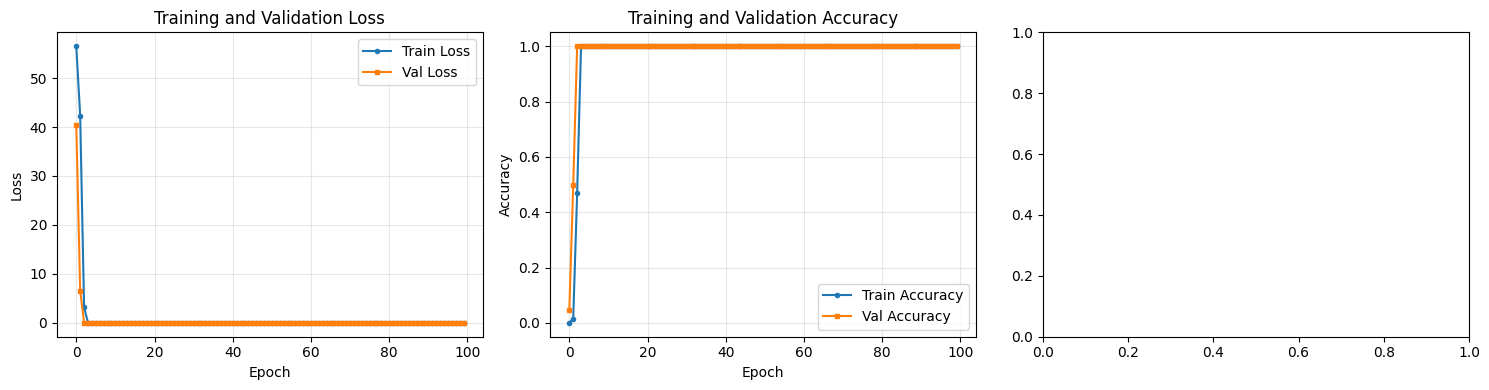


Final Training Metrics:
Train Loss:     0.0002
Train Accuracy: 1.0000
Val Loss:       0.0001
Val Accuracy:   1.0000
Val AUC-ROC:    nan


In [12]:
# Plot training history
plot_training_history(history)

# Print final metrics
print("\nFinal Training Metrics:")

print(f"Train Loss:     {history['train_loss'][-1]:.4f}")
print(f"Train Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Val Loss:       {history['val_loss'][-1]:.4f}")
print(f"Val Accuracy:   {history['val_acc'][-1]:.4f}")
print(f"Val AUC-ROC:    {history['val_auc'][-1]:.4f}")


In [13]:

print("Saving Results")


# Save model state
model_path = os.path.join(SAVE_DIR, f"{EXPERIMENT_NAME}_model.pt")
torch.save(model.state_dict(), model_path)
print(f"✓ Model saved: {model_path}")

# Save graph
graph_path = os.path.join(SAVE_DIR, f"{EXPERIMENT_NAME}_graph.pkl")
processor.save_graph(graph_path)
print(f"✓ Graph saved: {graph_path}")

# Save training history
from drug_patient_qgnn import save_training_history
history_path = os.path.join(SAVE_DIR, f"{EXPERIMENT_NAME}_history.json")
save_training_history(history, history_path)
print(f"✓ History saved: {history_path}")

# Save configuration
import json
config = {
    'experiment_name': EXPERIMENT_NAME,
    'timestamp': timestamp,
    'mode': mode,
    'num_qubits': NUM_QUBITS,
    'num_qlayers': NUM_QLAYERS,
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'val_split': VAL_SPLIT,
    'seed': SEED,
    'max_drugs': MAX_DRUGS,
    'n_patients': N_PATIENTS,
    'interaction_rate': INTERACTION_RATE
}

config_path = os.path.join(SAVE_DIR, f"{EXPERIMENT_NAME}_config.json")
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"✓ Config saved: {config_path}")


Saving Results
✓ Model saved: ./saved_models/spark_classical_q6_l2_20251128_140339_model.pt
Graph saved to ./saved_models/spark_classical_q6_l2_20251128_140339_graph.pkl
✓ Graph saved: ./saved_models/spark_classical_q6_l2_20251128_140339_graph.pkl
Training history saved to ./saved_models/spark_classical_q6_l2_20251128_140339_history.json
✓ History saved: ./saved_models/spark_classical_q6_l2_20251128_140339_history.json
✓ Config saved: ./saved_models/spark_classical_q6_l2_20251128_140339_config.json
